# Concatenating, Joining, and Pivoting Data

There are several ways of answering many questions in this notebook, but try to use the new operations (concatenate, joint/merge, pivot) whenever possible to get practice.

In [1]:
import pandas as pd

## Movie Ratings Data

The Movielens data set (https://dlsun.github.io/pods/data/ml-1m/ ) contains 1 million movie ratings submitted by users. The information about the movies, ratings, and users are stored in three separate files, called `movies.dat`, `ratings.dat`, and `users.dat`. The column names are not included with the data files. Refer to the webpage above for more information.


1\. Read in each of the data files.


(Hint: see the note in the documentation about the delimiter; use the `sep` argument in `read_csv`. If you get an error when reading the `movies.dat` file, try `encoding_errors = "ignore"` in `read_csv`.)

In [2]:
base = "https://dlsun.github.io/pods/data/ml-1m/"

movies_url = base + "movies.dat"
movies_df = pd.read_csv(movies_url, sep="::", encoding_errors="ignore", header = None, names = ["movie_id","title","genre"])

<positron-console-cell-2>:4: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.


In [3]:
ratings_url = base + "ratings.dat"
ratings_df = pd.read_csv(ratings_url, sep="::", encoding_errors="ignore", header = None, names = ["user_id","movie_id","rating","timestamp"])

<positron-console-cell-3>:2: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.


In [4]:
users_url = base + "users.dat"
users_df = pd.read_csv(users_url, sep="::", encoding_errors="ignore", header = None, names = ["user_id","gender","age","occupation","zip_code"])

<positron-console-cell-4>:2: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.


2\. Which age group tends to give the highest ratings? Create an appropriate summary to answer this question.

(Note the way age is coded in the [REAMDE file](https://dlsun.github.io/pods/data/ml-1m/README.txt).)

In [5]:
rating_users_df = ratings_df.merge(users_df, on="user_id", how="left", validate = "many_to_one")
age_label = {1:"<18", 18:"18-24", 25:"25-34", 35:"35-44", 45:"45-49", 50:"50-55", 56:"56+"}
rating_users_df["age_group"]=rating_users_df["age"].map(age_label)
rating_users_df.groupby("age_group")["rating"].agg(n_rating = "size", mean_rating = "mean").sort_values("mean_rating", ascending=False).reset_index()



,age_group,n_rating,mean_rating
0,56+,38780,3.766632
1,50-55,72490,3.714512
2,45-49,83633,3.638062
3,35-44,199003,3.618162
4,<18,27211,3.549520
5,25-34,395556,3.545235
6,18-24,183536,3.507573


3\. Among movies with at least 100 ratings, which movies had the highest average rating? The lowest?

In [6]:
movie_stats = ratings_df.groupby("movie_id")["rating"].agg(n_rating = "size", mean_rating = "mean").reset_index()

movie_stats_100 = movie_stats[movie_stats["n_rating"] >= 100]

# Sort by highest rating
movie_stats_100.merge(movies_df, on="movie_id", how="left").sort_values(by='mean_rating', ascending=False)


,movie_id,n_rating,mean_rating,title,genre
1021,2019,628,4.560510,Seven Samurai (The Magnificent Seven) (Shichin...,Action|Drama
173,318,2227,4.554558,"Shawshank Redemption, The (1994)",Drama
416,858,2223,4.524966,"Godfather, The (1972)",Action|Crime|Drama
377,745,657,4.520548,"Close Shave, A (1995)",Animation|Comedy|Thriller
39,50,1783,4.517106,"Usual Suspects, The (1995)",Crime|Thriller
...,...,...,...,...,...
1244,2383,149,1.657718,Police Academy 6: City Under Siege (1989),Comedy
1478,2817,125,1.640000,Aces: Iron Eagle III (1992),Action|War
1959,3799,100,1.620000,Pokmon the Movie 2000 (2000),Animation|Children's
1859,3593,342,1.611111,Battlefield Earth (2000),Action|Sci-Fi


In [7]:
# Sort by lowest rating
movie_stats_100.merge(movies_df, on="movie_id", how="left").sort_values(by='mean_rating')

,movie_id,n_rating,mean_rating,title,genre
401,810,120,1.466667,Kazaam (1996),Children's|Comedy|Fantasy
1859,3593,342,1.611111,Battlefield Earth (2000),Action|Sci-Fi
1959,3799,100,1.620000,Pokmon the Movie 2000 (2000),Animation|Children's
1478,2817,125,1.640000,Aces: Iron Eagle III (1992),Action|War
1244,2383,149,1.657718,Police Academy 6: City Under Siege (1989),Comedy
...,...,...,...,...,...
39,50,1783,4.517106,"Usual Suspects, The (1995)",Crime|Thriller
377,745,657,4.520548,"Close Shave, A (1995)",Animation|Comedy|Thriller
416,858,2223,4.524966,"Godfather, The (1972)",Action|Crime|Drama
173,318,2227,4.554558,"Shawshank Redemption, The (1994)",Drama


4\. For each movie, calculate the average rating and the proportion of the ratings that were from users aged 18-24. Make a scatterplot showing the relationship between the average rating and the 18-24 share, with each point representing a movie. (Optional: Use the size of each point to represent the number of users who rated the movie.)

In [8]:
# Calculate average rating for each movie ID and number of ratings from users aged 18-24
rating_users_df["age_18"] = rating_users_df["age"] == 18
rating_stats = rating_users_df.groupby("movie_id").agg(n_rating = ("rating","size"), mean_rating = ("rating","mean"), n_rating_age_18 = ("age_18", "sum")).reset_index()


# For each movie ID, divide number of ratings from 18-24 by total num ratings
rating_stats["prop_age_18"] = (rating_stats["n_rating_age_18"]/rating_stats["n_rating"])
rating_stats


,movie_id,n_rating,mean_rating,n_rating_age_18,prop_age_18
0,1,2077,4.146846,448,0.215696
1,2,701,3.201141,154,0.219686
2,3,478,3.016736,107,0.223849
3,4,170,2.729412,39,0.229412
4,5,296,3.006757,65,0.219595
...,...,...,...,...,...
3701,3948,862,3.635731,190,0.220418
3702,3949,304,4.115132,82,0.269737
3703,3950,54,3.666667,12,0.222222
3704,3951,40,3.900000,3,0.075000


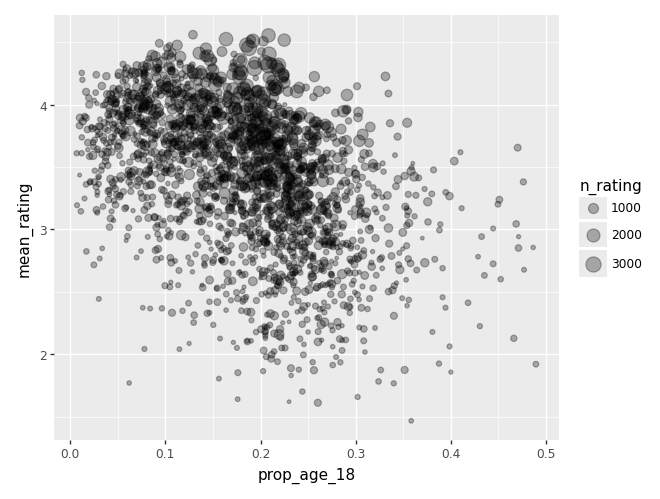

In [9]:
from plotnine import *
(ggplot(rating_stats[rating_stats["n_rating"] >= 100], aes(x = "prop_age_18", y = "mean_rating", size = "n_rating"))
 + geom_point(alpha=0.3)
 + scale_size(range=(1,6))
)

5\. Calculate the number of ratings by movie. How many of the movies had zero ratings?

(_Hint_: Why is an inner join not sufficient here?)

In [10]:
ratings_movies_df = movies_df.merge(ratings_df, on="movie_id", how="left")
ratings_movies_df[["user_id","rating","timestamp"]] = ratings_movies_df[["user_id","rating","timestamp"]].astype("Int64")
(ratings_movies_df.
    groupby("movie_id")["rating"].
    agg(n_rating = "count", mean_rating = "mean").
    reset_index().
    sort_values(by="n_rating")["n_rating"] == 0
).sum()

np.int64(177)

6\. How many movies received both a 1 and a 5 rating? Which movies? How many ratings of each type (1 or 5 stars)? Answer these question by joining two appropriate tables.

In [11]:
# Find movies where rating contains 1 or 5
ratings_1or5 = ratings_movies_df[ratings_movies_df["rating"].isin([1,5])]

# Count how many 1's and 5's
rating_counts = ratings_1or5.groupby(["movie_id","title","rating"]).size().unstack(fill_value=0).reset_index()

# Find movies that received at least one 1 and at least one 5
ratings_1and5 = rating_counts[
    (rating_counts[1] > 0) &
    (rating_counts[5] > 0)
]

# Count how many received both ratings
len(ratings_1and5)

2986

In [12]:
# Which movies received both ratings and how many ratings of each type
ratings_1and5[["movie_id","title", 1, 5]]

rating,movie_id,title,1,5
0,1,Toy Story (1995),16,820
1,2,Jumanji (1995),42,48
2,3,Grumpier Old Men (1995),44,43
3,4,Waiting to Exhale (1995),21,6
4,5,Father of the Bride Part II (1995),28,16
...,...,...,...,...
3515,3948,Meet the Parents (2000),35,163
3516,3949,Requiem for a Dream (2000),9,132
3517,3950,Tigerland (2000),2,12
3518,3951,Two Family House (2000),1,14
